In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv("/Users/senarajayawardena/Desktop/IIT 2y/SEM 02/Data Science /ICW/Data Science/UN_SDG_ER_RSK_LBREDS.csv")

In [3]:
print(df.shape)

(3588, 41)


In [4]:
print(df.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL']


In [5]:
# Summary statistics
print(df.describe())

       TIME_PERIOD    OBS_VALUE  DECIMALS  TIME_FORMAT  UNIT_MULT
count  3588.000000  2366.000000    3588.0       3588.0     3588.0
mean   2012.500000    49.478022       2.0        602.0        0.0
std       7.501045    37.445528       0.0          0.0        0.0
min    2000.000000     0.000000       2.0        602.0        0.0
25%    2006.000000    11.000000       2.0        602.0        0.0
50%    2012.500000    50.000000       2.0        602.0        0.0
75%    2019.000000    86.000000       2.0        602.0        0.0
max    2025.000000   100.000000       2.0        602.0        0.0


In [6]:
# Count missing values
print(df.isnull().sum())

STRUCTURE                    0
STRUCTURE_ID                 0
ACTION                       0
FREQ                         0
REF_AREA                     0
INDICATOR                    0
SEX                          0
AGE                          0
URBANISATION                 0
UNIT_MEASURE                 0
COMP_BREAKDOWN_1             0
COMP_BREAKDOWN_2             0
COMP_BREAKDOWN_3             0
TIME_PERIOD                  0
OBS_VALUE                 1222
AGG_METHOD                   0
UNIT_TYPE                    0
DECIMALS                     0
DATABASE_ID                  0
TIME_FORMAT                  0
UNIT_MULT                    0
OBS_STATUS                   0
OBS_CONF                     0
FREQ_LABEL                   0
REF_AREA_LABEL               0
INDICATOR_LABEL              0
SEX_LABEL                    0
AGE_LABEL                    0
URBANISATION_LABEL           0
UNIT_MEASURE_LABEL           0
COMP_BREAKDOWN_1_LABEL       0
COMP_BREAKDOWN_2_LABEL       0
COMP_BRE

In [7]:
df=df.drop_duplicates()


In [8]:
# Keep only the columns we need
df = df[["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE", "OBS_STATUS_LABEL"]]

In [9]:
# Rename for simplicity
df = df.rename(columns={
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "pct_at_risk",
    "OBS_STATUS_LABEL": "status"
})

In [15]:
# Convert Year to numeric
if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [18]:
# Drop rows where the value is missing
df = df.dropna(subset=["pct_at_risk"])

In [19]:
# Fix types
df["year"] = df["year"].astype(int)
df["pct_at_risk"] = df["pct_at_risk"].astype(float)
df["country"] = df["country"].str.strip()


In [20]:
# Drop duplicates
df = df.drop_duplicates()


In [21]:

print("\nCleaned shape:", df.shape)
print(df.head(10))




Cleaned shape: (2366, 4)
    country  year  pct_at_risk        status
2   Denmark  2000         83.0  Normal value
3   Denmark  2001         83.0  Normal value
4   Denmark  2002         83.0  Normal value
5   Denmark  2003         83.0  Normal value
6   Denmark  2004         94.0  Normal value
7   Denmark  2005         95.0  Normal value
8   Denmark  2006         95.0  Normal value
9   Denmark  2007         95.0  Normal value
10  Denmark  2008        100.0  Normal value
11  Denmark  2009        100.0  Normal value


In [25]:

df.to_csv("clean.csv", index=False)
print("clean.csv")

clean.csv


EDA

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("clean.csv")

print("Shape:", df.shape)
print("Countries:", df["country"].nunique())
print("Year range:", df["year"].min(), "-", df["year"].max())
print(df.describe())

Shape: (2366, 4)
Countries: 138
Year range: 2000 - 2025
              year  pct_at_risk
count  2366.000000  2366.000000
mean   2011.368555    49.478022
std       7.557996    37.445528
min    2000.000000     0.000000
25%    2005.000000    11.000000
50%    2010.000000    50.000000
75%    2018.000000    86.000000
max    2025.000000   100.000000


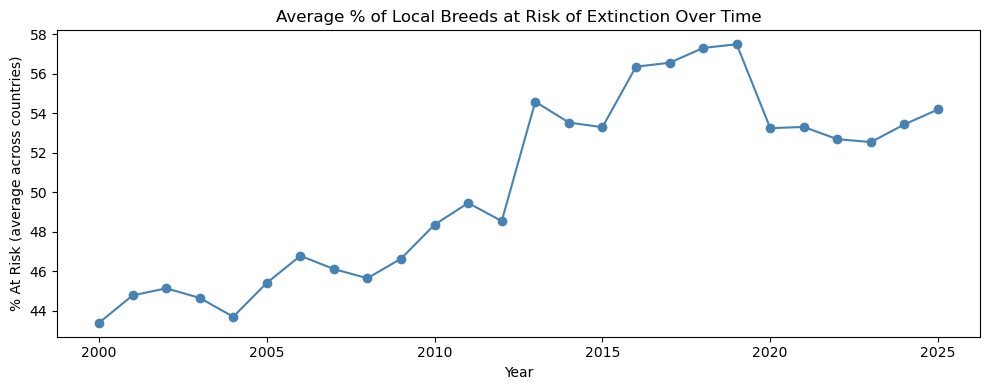

In [28]:
# -- Plot 1: Global average % at risk over time --
yearly = df.groupby("year")["pct_at_risk"].mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker="o", color="steelblue")
plt.title("Average % of Local Breeds at Risk of Extinction Over Time")
plt.xlabel("Year")
plt.ylabel("% At Risk (average across countries)")
plt.tight_layout()
plt.show()

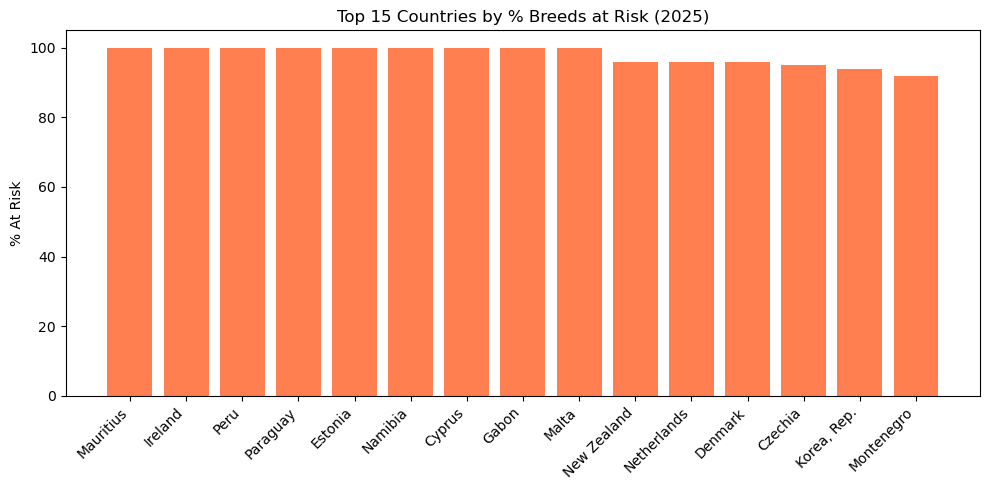

In [30]:
# -- Plot 2: Top 15 countries with highest % at risk (latest available year) --
latest_year = df["year"].max()
latest = df[df["year"] == latest_year].sort_values("pct_at_risk", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(latest["country"], latest["pct_at_risk"], color="coral")
plt.title(f"Top 15 Countries by % Breeds at Risk ({latest_year})")
plt.ylabel("% At Risk")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


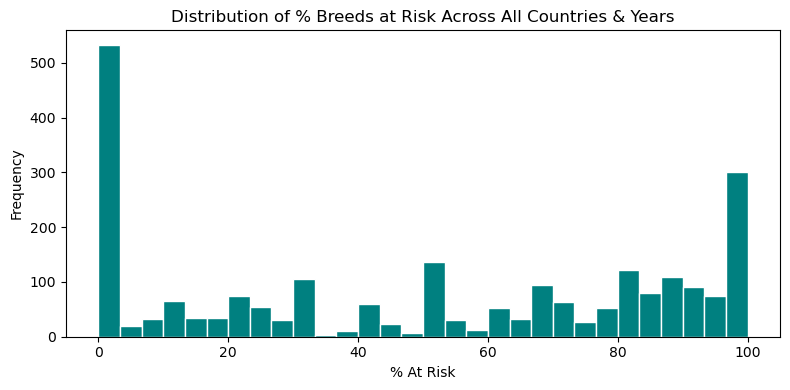

In [31]:
# -- Plot 3: Distribution of % at risk values --
plt.figure(figsize=(8, 4))
df["pct_at_risk"].plot(kind="hist", bins=30, color="teal", edgecolor="white")
plt.title("Distribution of % Breeds at Risk Across All Countries & Years")
plt.xlabel("% At Risk")
plt.tight_layout()
plt.show()